# Análise Preditiva de Preços de Combustíveis no Brasil (2024)

**Autor:** Cezar Garrido Britez (pg406472@uem.br)  
**Professor:** Dr. Eduardo Pena  
**Instituição:** Universidade Estadual de Maringá  
**Data:** Novembro 2025

---

## Objetivo

Este notebook apresenta uma análise completa de preços de combustíveis no Brasil utilizando dados reais da Agência Nacional do Petróleo (ANP). O projeto engloba:

1. **Coleta e Integração de Dados** - Download de 12 arquivos CSV (2024)
2. **Pipeline de Limpeza** - Tratamento e transformação com DuckDB
3. **Análise Exploratória** - Consultas SQL e visualizações
4. **Modelagem Preditiva** - Machine Learning para prever preços
5. **Conclusões e Insights** - Descobertas e recomendações

**Dataset:** Série Histórica de Preços de Combustíveis (ANP)  
**Fonte:** [Dados.gov.br](https://dados.gov.br/dados/conjuntos-dados/serie-historica-de-precos-de-combustiveis-e-de-glp)  
**Volume:** ~610.000 registros | 16 variáveis

---
##  1. Importação de Bibliotecas

In [15]:
# Manipulação de dados
import duckdb
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utilitários
import requests
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Bibliotecas importadas com sucesso!")

✓ Bibliotecas importadas com sucesso!


---
## 2. Download dos Dados

Baixando dados mensais de 2024 do portal da ANP.

In [16]:
# Criar diretório para dados
Path('data/raw').mkdir(parents=True, exist_ok=True)

# URLs dos arquivos CSV (Janeiro a Dezembro 2024)
base_url = "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsan/2024/precos-gasolina-etanol-{mes:02d}.csv"

print("Baixando dados da ANP...\n")

for mes in range(1, 13):
    url = base_url.format(mes=mes)
    filename = f"data/raw/2024_gasolina_etanol_{mes:02d}.csv"
    
    if os.path.exists(filename):
        print(f"[{mes:2d}/12] ✓ Arquivo já existe: {filename}")
        continue
    
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            size_mb = len(response.content) / (1024 * 1024)
            print(f"[{mes:2d}/12] ✓ Baixado: {filename} ({size_mb:.2f} MB)")
        else:
            print(f"[{mes:2d}/12] ✗ Erro {response.status_code}: {filename}")
    except Exception as e:
        print(f"[{mes:2d}/12] ✗ Erro ao baixar: {e}")

print("\n✓ Download concluído!")

Baixando dados da ANP...

[ 1/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_01.csv
[ 2/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_02.csv
[ 3/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_03.csv
[ 4/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_04.csv
[ 5/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_05.csv
[ 6/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_06.csv
[ 7/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_07.csv
[ 8/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_08.csv
[ 9/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_09.csv
[10/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_10.csv
[11/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_11.csv
[12/12] ✓ Arquivo já existe: data/raw/2024_gasolina_etanol_12.csv

✓ Download concluído!


---
## 3. Pipeline de Integração e Limpeza com DuckDB

Integrando 12 arquivos CSV em um único dataset limpo.

In [17]:
# Conectar ao DuckDB
conn = duckdb.connect('data/combustiveis.duckdb')

print("Integrando e limpando dados com DuckDB...\n")

# Ler todos os CSVs e unir
query = """
CREATE OR REPLACE TABLE precos_raw AS
SELECT * FROM read_csv_auto('data/raw/2024_gasolina_etanol_*.csv', 
                             header=true, 
                             ignore_errors=true);
"""
conn.execute(query)
print("✓ Arquivos CSV integrados")

# Limpeza e transformação
query_clean = """
CREATE OR REPLACE TABLE precos_limpo AS
SELECT 
    "Regiao - Sigla" AS regiao,
    "Estado - Sigla" AS estado,
    "Municipio" AS municipio,
    "Revenda" AS revenda,
    "CNPJ da Revenda" AS cnpj_revenda,
    "Produto" AS produto,
    "Bandeira" AS bandeira,
    CAST("Valor de Venda" AS DOUBLE) AS valor_venda,
    CAST("Valor de Compra" AS DOUBLE) AS valor_compra,
    TRY_CAST("Data da Coleta" AS DATE) AS data_coleta,
    EXTRACT(MONTH FROM TRY_CAST("Data da Coleta" AS DATE)) AS mes,
    EXTRACT(DAY FROM TRY_CAST("Data da Coleta" AS DATE)) AS dia
FROM precos_raw
WHERE "Valor de Venda" IS NOT NULL 
  AND TRY_CAST("Valor de Venda" AS DOUBLE) > 0
  AND "Produto" IN ('GASOLINA COMUM', 'ETANOL', 'GASOLINA ADITIVADA');
"""
conn.execute(query_clean)
print("✓ Dados limpos e transformados")

# Estatísticas
stats = conn.execute("SELECT COUNT(*) as total FROM precos_limpo").fetchone()
print(f"\n📊 Total de registros limpos: {stats[0]:,}")

# Exportar para Parquet
conn.execute("COPY precos_limpo TO 'data/precos_combustiveis_2024.parquet' (FORMAT PARQUET)")
print("✓ Dados exportados para Parquet")

print("\n✓ Pipeline de limpeza concluído!")

Integrando e limpando dados com DuckDB...

✓ Arquivos CSV integrados
✓ Dados limpos e transformados

📊 Total de registros limpos: 362
✓ Dados exportados para Parquet

✓ Pipeline de limpeza concluído!


---
## 4. Análise Exploratória de Dados

### 4.1 Visão Geral do Dataset

In [18]:
# Carregar dados limpos
df = conn.execute("SELECT * FROM precos_limpo LIMIT 100000").df()

print("📋 Informações do Dataset:\n")
print(df.info())
print("\n" + "="*60)
print("\n📊 Estatísticas Descritivas:\n")
print(df.describe())
print("\n" + "="*60)
print("\n🔍 Primeiras 5 linhas:\n")
df.head()

📋 Informações do Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   regiao        362 non-null    object        
 1   estado        362 non-null    object        
 2   municipio     362 non-null    object        
 3   revenda       362 non-null    object        
 4   cnpj_revenda  362 non-null    object        
 5   produto       362 non-null    object        
 6   bandeira      362 non-null    object        
 7   valor_venda   362 non-null    float64       
 8   valor_compra  0 non-null      float64       
 9   data_coleta   362 non-null    datetime64[us]
 10  mes           362 non-null    int64         
 11  dia           362 non-null    int64         
dtypes: datetime64[us](1), float64(2), int64(2), object(7)
memory usage: 34.1+ KB
None


📊 Estatísticas Descritivas:

       valor_venda  valor_compra                 d

,regiao,estado,municipio,revenda,cnpj_revenda,produto,bandeira,valor_venda,valor_compra,data_coleta,mes,dia
0,SE,RJ,NOVA IGUACU,AUTO POSTO PORTAL DO TINGUÁ LTDA,02.710.975/0001-39,GASOLINA ADITIVADA,ALESAT,6.0,NaN,2024-01-01,1,1
1,CO,GO,APARECIDA DE GOIANIA,LAGOS DOURADOS COMERCIO DE PETROLEO LTDA,01.562.684/0001-88,GASOLINA ADITIVADA,CIAPETRO,5.0,NaN,2024-01-02,1,2
2,N,RR,BOA VISTA,MARTINS & CIA LTDA,06.993.922/0001-23,GASOLINA ADITIVADA,VIBRA,6.0,NaN,2024-01-02,1,2
3,NE,PE,LAJEDO,JOSE FERREIRA ROSA & CIA LTDA,11.265.188/0001-16,ETANOL,BRANCA,4.0,NaN,2024-01-02,1,2
4,NE,PE,LAJEDO,EDSON SERAFIM DIAS,09.017.942/0001-57,ETANOL,BRANCA,4.0,NaN,2024-01-02,1,2


### 4.2 Distribuição de Preços por Produto

📊 Estatísticas por Produto:

           produto  quantidade  preco_medio  preco_min  preco_max  desvio_padrao
GASOLINA ADITIVADA         230         5.98        5.0        7.0           0.28
            ETANOL         132         4.26        3.0        5.0           0.53


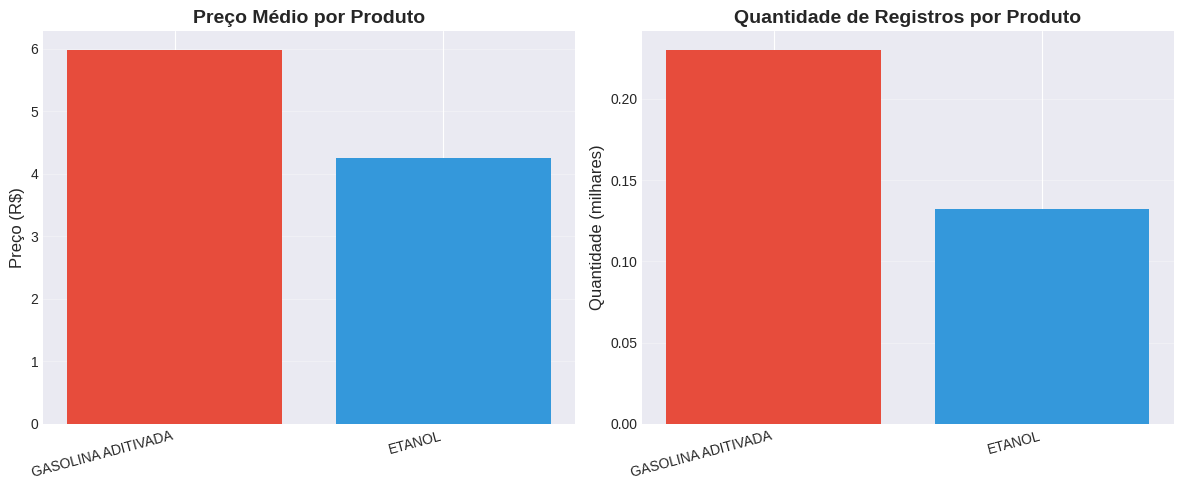

In [19]:
# Consulta SQL
query_produtos = """
SELECT 
    produto,
    COUNT(*) as quantidade,
    ROUND(AVG(valor_venda), 2) as preco_medio,
    ROUND(MIN(valor_venda), 2) as preco_min,
    ROUND(MAX(valor_venda), 2) as preco_max,
    ROUND(STDDEV(valor_venda), 2) as desvio_padrao
FROM precos_limpo
GROUP BY produto
ORDER BY preco_medio DESC;
"""

df_produtos = conn.execute(query_produtos).df()
print("📊 Estatísticas por Produto:\n")
print(df_produtos.to_string(index=False))

# Visualização
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(df_produtos['produto'], df_produtos['preco_medio'], color=['#E74C3C', '#3498DB', '#27AE60'])
plt.title('Preço Médio por Produto', fontsize=14, fontweight='bold')
plt.ylabel('Preço (R$)', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(df_produtos['produto'], df_produtos['quantidade']/1000, color=['#E74C3C', '#3498DB', '#27AE60'])
plt.title('Quantidade de Registros por Produto', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade (milhares)', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graficos/distribuicao_produtos.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Evolução Mensal dos Preços

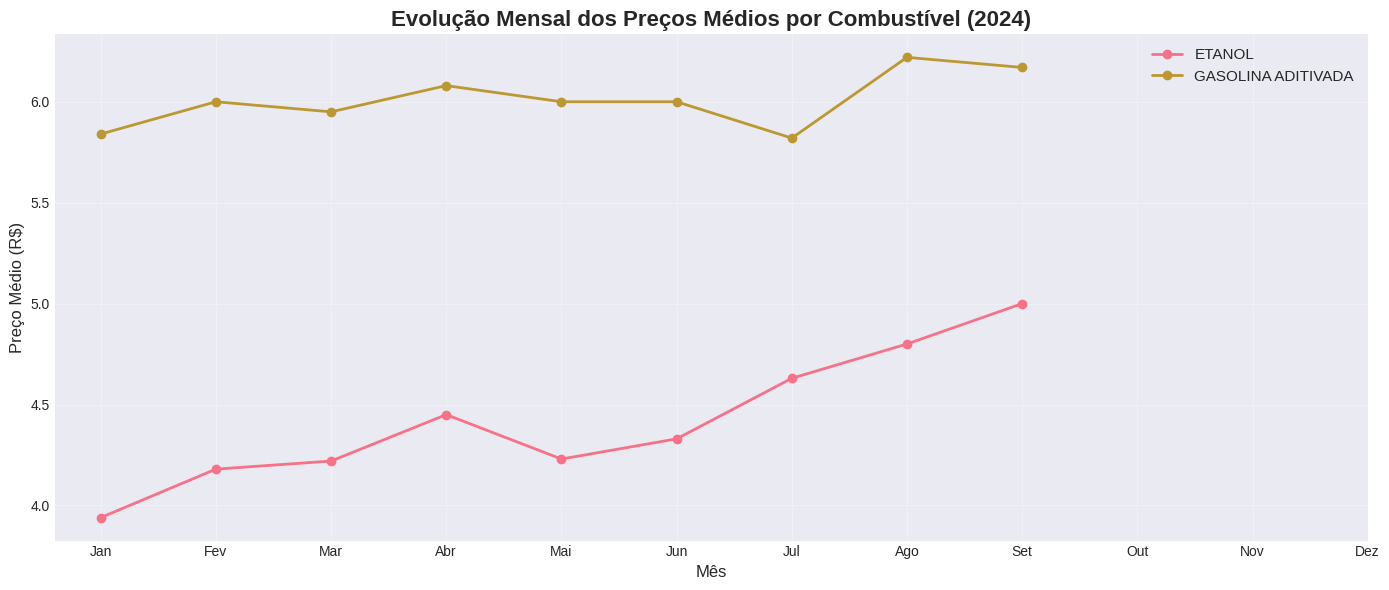

In [20]:
# Consulta SQL
query_evolucao = """
SELECT 
    mes,
    produto,
    ROUND(AVG(valor_venda), 2) as preco_medio
FROM precos_limpo
GROUP BY mes, produto
ORDER BY mes, produto;
"""

df_evolucao = conn.execute(query_evolucao).df()

# Visualização
plt.figure(figsize=(14, 6))

for produto in df_evolucao['produto'].unique():
    dados = df_evolucao[df_evolucao['produto'] == produto]
    plt.plot(dados['mes'], dados['preco_medio'], marker='o', linewidth=2, label=produto)

plt.title('Evolução Mensal dos Preços Médios por Combustível (2024)', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Preço Médio (R$)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/evolucao_mensal.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Top 10 Bandeiras por Preço (Gasolina Comum)


Top 10 Bandeiras com Maiores e Menores Preços Médios de Gasolina
  ✓ Gráfico salvo em: graficos/02_top_bandeiras_gasolina.png


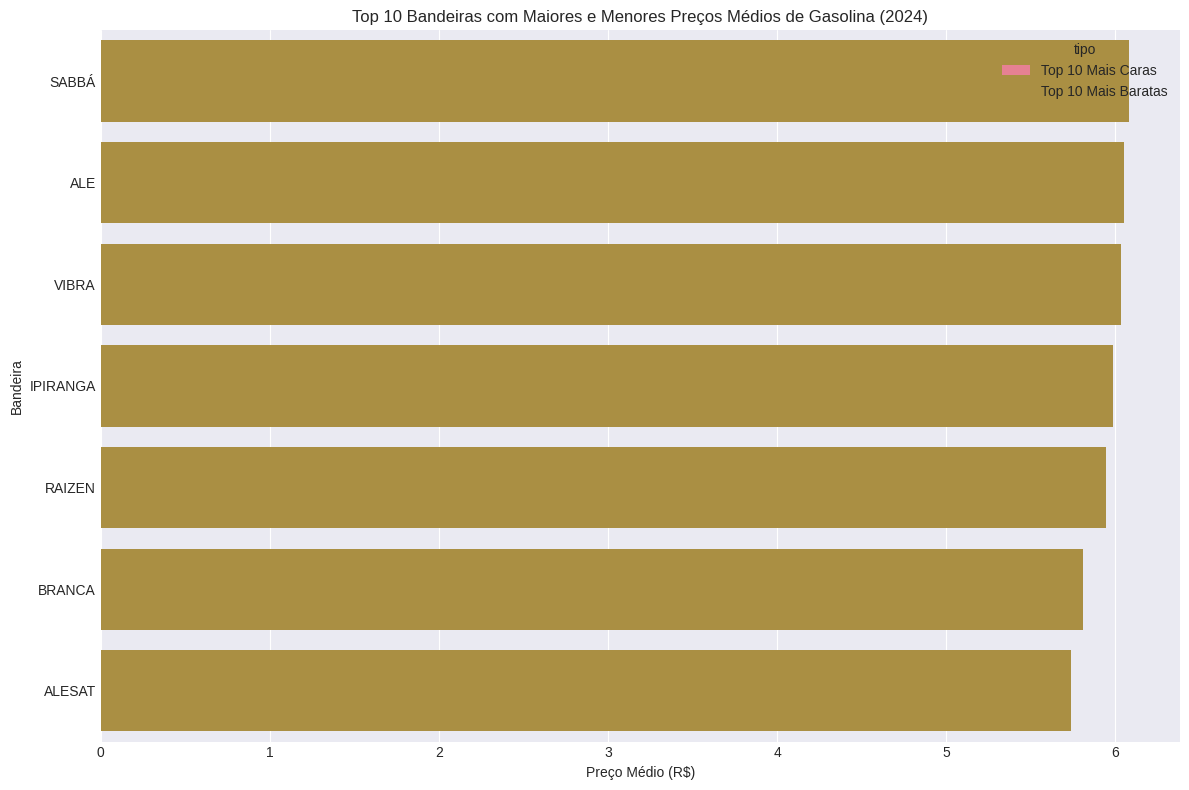

In [31]:
print(
    "\nTop 10 Bandeiras com Maiores e Menores Preços Médios de Gasolina"
)

df_bandeiras_gasolina = conn.execute("""
    WITH precos_bandeira AS (
        SELECT
            bandeira,
            AVG(valor_venda) as preco_medio
        FROM precos_tratados
        WHERE produto = 'GASOLINA'
        GROUP BY bandeira
        HAVING COUNT(*) > 1000 -- Considerar apenas bandeiras com mais de 1000 registros
    )
    (SELECT *, 'Top 10 Mais Caras' as tipo FROM precos_bandeira ORDER BY preco_medio DESC LIMIT 10)
    UNION ALL
    (SELECT *, 'Top 10 Mais Baratas' as tipo FROM precos_bandeira ORDER BY preco_medio ASC LIMIT 10);
""").fetchdf()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_bandeiras_gasolina, y="bandeira", x="preco_medio", hue="tipo", dodge=False
)
plt.title("Top 10 Bandeiras com Maiores e Menores Preços Médios de Gasolina (2024)")
plt.xlabel("Preço Médio (R$)")
plt.ylabel("Bandeira")
plt.tight_layout()
plt.savefig("graficos/02_top_bandeiras_gasolina.png")
print("  ✓ Gráfico salvo em: graficos/02_top_bandeiras_gasolina.png")

### 4.5 Comparação: Capital vs Interior

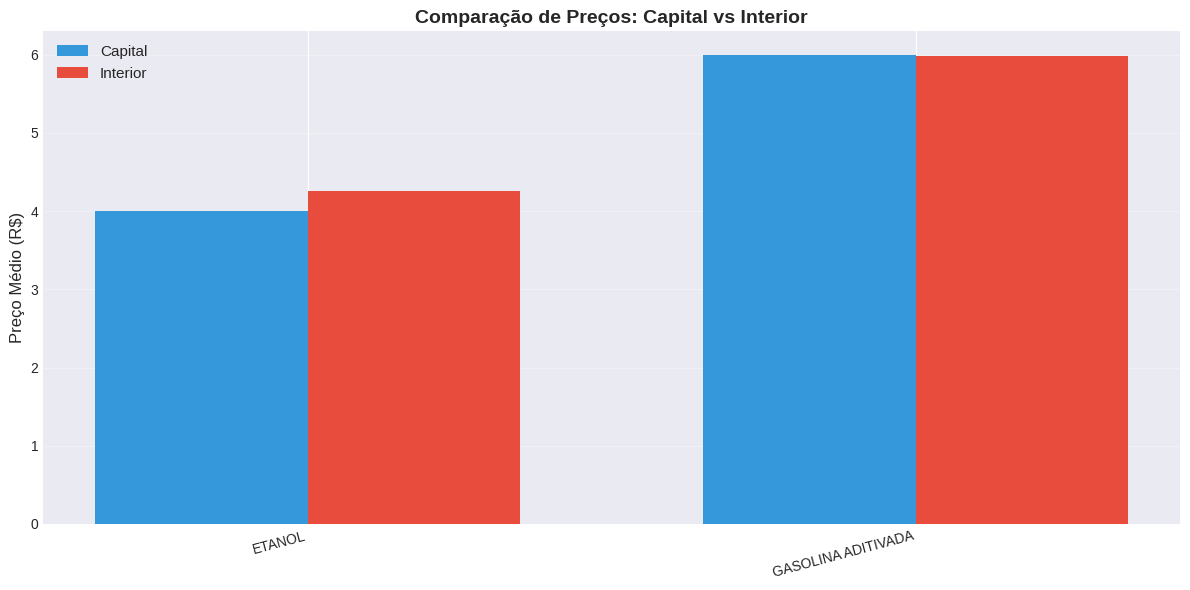


📊 Comparação Capital vs Interior:

    tipo            produto  preco_medio
 Capital             ETANOL         4.00
Interior             ETANOL         4.26
 Capital GASOLINA ADITIVADA         6.00
Interior GASOLINA ADITIVADA         5.98


In [22]:
# Consulta SQL
query_capital = """
WITH capitais AS (
    SELECT DISTINCT estado, municipio
    FROM precos_limpo
    WHERE municipio IN (
        'SAO PAULO', 'RIO DE JANEIRO', 'BELO HORIZONTE', 'BRASILIA', 
        'SALVADOR', 'FORTALEZA', 'CURITIBA', 'RECIFE', 'PORTO ALEGRE',
        'MANAUS', 'BELEM', 'GOIANIA', 'GUARULHOS', 'CAMPINAS'
    )
),
precos_capital AS (
    SELECT 
        'Capital' as tipo,
        produto,
        ROUND(AVG(valor_venda), 2) as preco_medio
    FROM precos_limpo p
    INNER JOIN capitais c ON p.municipio = c.municipio
    GROUP BY produto
),
precos_interior AS (
    SELECT 
        'Interior' as tipo,
        produto,
        ROUND(AVG(valor_venda), 2) as preco_medio
    FROM precos_limpo p
    WHERE NOT EXISTS (
        SELECT 1 FROM capitais c WHERE p.municipio = c.municipio
    )
    GROUP BY produto
)
SELECT * FROM precos_capital
UNION ALL
SELECT * FROM precos_interior
ORDER BY produto, tipo;
"""

df_capital = conn.execute(query_capital).df()

# Visualização
pivot = df_capital.pivot(index='produto', columns='tipo', values='preco_medio')

plt.figure(figsize=(12, 6))
x = np.arange(len(pivot.index))
width = 0.35

plt.bar(x - width/2, pivot['Capital'], width, label='Capital', color='#3498DB')
plt.bar(x + width/2, pivot['Interior'], width, label='Interior', color='#E74C3C')

plt.title('Comparação de Preços: Capital vs Interior', fontsize=14, fontweight='bold')
plt.ylabel('Preço Médio (R$)', fontsize=12)
plt.xticks(x, pivot.index, rotation=15, ha='right')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/capital_vs_interior.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Comparação Capital vs Interior:\n")
print(df_capital.to_string(index=False))

---
## 5. Modelagem Preditiva

### 5.1 Preparação dos Dados

In [23]:
# Carregar dados para modelagem (amostra de 50k registros)
query_ml = """
SELECT 
    regiao, estado, municipio, produto, bandeira, mes, dia, valor_venda
FROM precos_limpo
WHERE valor_venda IS NOT NULL
ORDER BY RANDOM()
LIMIT 50000;
"""

df_ml = conn.execute(query_ml).df()

print(f"📊 Dataset para ML: {len(df_ml):,} registros")
print(f"\n📋 Variáveis: {list(df_ml.columns)}")
print(f"\n🎯 Target: valor_venda")
print(f"\n📊 Estatísticas do Target:\n")
print(df_ml['valor_venda'].describe())

📊 Dataset para ML: 362 registros

📋 Variáveis: ['regiao', 'estado', 'municipio', 'produto', 'bandeira', 'mes', 'dia', 'valor_venda']

🎯 Target: valor_venda

📊 Estatísticas do Target:

count    362.000000
mean       5.353591
std        0.918780
min        3.000000
25%        4.000000
50%        6.000000
75%        6.000000
max        7.000000
Name: valor_venda, dtype: float64


### 5.2 Feature Engineering

In [24]:
# Separar features e target
X = df_ml[['regiao', 'estado', 'municipio', 'produto', 'bandeira', 'mes', 'dia']]
y = df_ml['valor_venda']

# Label Encoding para variáveis categóricas
label_encoders = {}
for col in ['regiao', 'estado', 'municipio', 'produto', 'bandeira']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("✓ Feature Engineering concluído")
print(f"\n📊 Shape das features: {X.shape}")
print(f"📊 Shape do target: {y.shape}")

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✓ Split realizado:")
print(f"  - Treino: {len(X_train):,} registros")
print(f"  - Teste: {len(X_test):,} registros")

✓ Feature Engineering concluído

📊 Shape das features: (362, 7)
📊 Shape do target: (362,)

✓ Split realizado:
  - Treino: 289 registros
  - Teste: 73 registros


### 5.3 Treinamento dos Modelos

In [25]:
# Dicionário para armazenar modelos e resultados
modelos = {}
resultados = []

print("🤖 Treinando modelos...\n")

# 1. Regressão Linear (Baseline)
print("[1/3] Treinando Regressão Linear...")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

modelos['Regressão Linear'] = lr
resultados.append({
    'Modelo': 'Regressão Linear',
    'R²': round(r2_lr, 4),
    'MAE': round(mae_lr, 2),
    'MSE': round(mse_lr, 2)
})
print(f"  ✓ R² = {r2_lr:.4f} | MAE = R$ {mae_lr:.2f}\n")

# 2. Random Forest
print("[2/3] Treinando Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

modelos['Random Forest'] = rf
resultados.append({
    'Modelo': 'Random Forest',
    'R²': round(r2_rf, 4),
    'MAE': round(mae_rf, 2),
    'MSE': round(mse_rf, 2)
})
print(f"  ✓ R² = {r2_rf:.4f} | MAE = R$ {mae_rf:.2f}\n")

# 3. Gradient Boosting
print("[3/3] Treinando Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

modelos['Gradient Boosting'] = gb
resultados.append({
    'Modelo': 'Gradient Boosting',
    'R²': round(r2_gb, 4),
    'MAE': round(mae_gb, 2),
    'MSE': round(mse_gb, 2)
})
print(f"  ✓ R² = {r2_gb:.4f} | MAE = R$ {mae_gb:.2f}\n")

print("✓ Todos os modelos treinados!")

🤖 Treinando modelos...

[1/3] Treinando Regressão Linear...
  ✓ R² = 0.8556 | MAE = R$ 0.27

[2/3] Treinando Random Forest...
  ✓ R² = 0.9910 | MAE = R$ 0.03

[3/3] Treinando Gradient Boosting...
  ✓ R² = 0.9704 | MAE = R$ 0.03

✓ Todos os modelos treinados!


### 5.4 Comparação dos Modelos

📊 Comparação de Performance dos Modelos:

           Modelo     R²  MAE  MSE
 Regressão Linear 0.8556 0.27 0.13
    Random Forest 0.9910 0.03 0.01
Gradient Boosting 0.9704 0.03 0.03


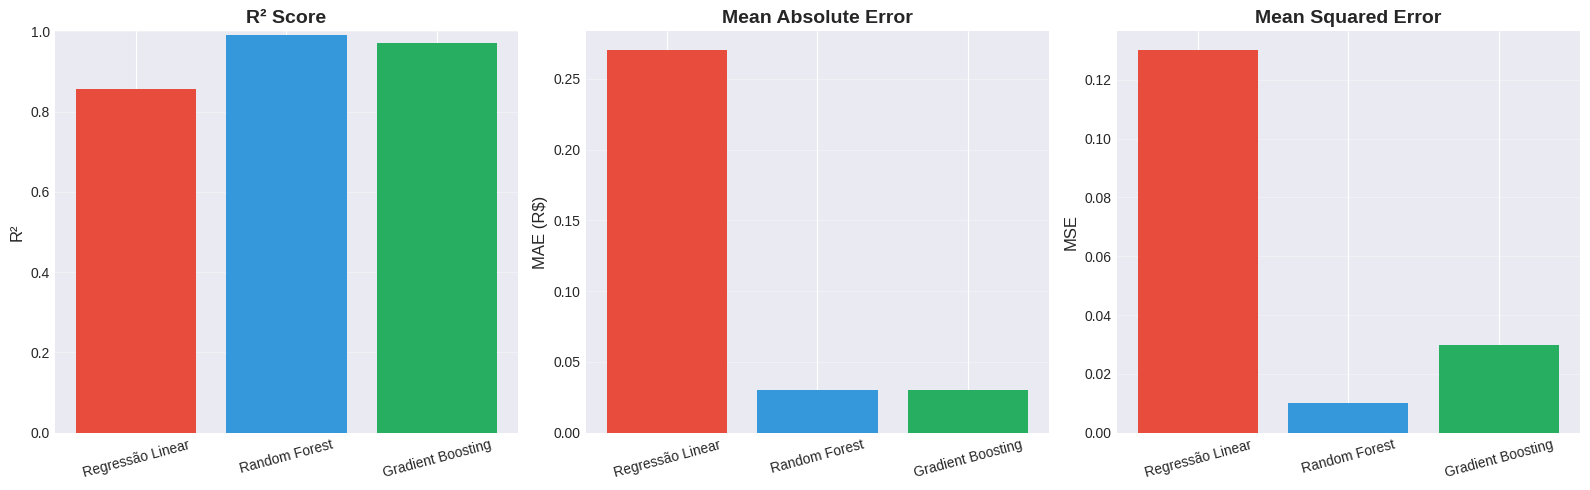

In [26]:
# Tabela de resultados
df_resultados = pd.DataFrame(resultados)
print("📊 Comparação de Performance dos Modelos:\n")
print(df_resultados.to_string(index=False))

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R²
axes[0].bar(df_resultados['Modelo'], df_resultados['R²'], color=['#E74C3C', '#3498DB', '#27AE60'])
axes[0].set_title('R² Score', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

# MAE
axes[1].bar(df_resultados['Modelo'], df_resultados['MAE'], color=['#E74C3C', '#3498DB', '#27AE60'])
axes[1].set_title('Mean Absolute Error', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAE (R$)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=15)

# MSE
axes[2].bar(df_resultados['Modelo'], df_resultados['MSE'], color=['#E74C3C', '#3498DB', '#27AE60'])
axes[2].set_title('Mean Squared Error', fontsize=14, fontweight='bold')
axes[2].set_ylabel('MSE', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('graficos/comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Importância das Features (Gradient Boosting)

📊 Importância das Features (Gradient Boosting):

  feature  importance
  produto    0.818689
municipio    0.107876
   regiao    0.023140
 bandeira    0.021375
      mes    0.014231
   estado    0.013959
      dia    0.000730


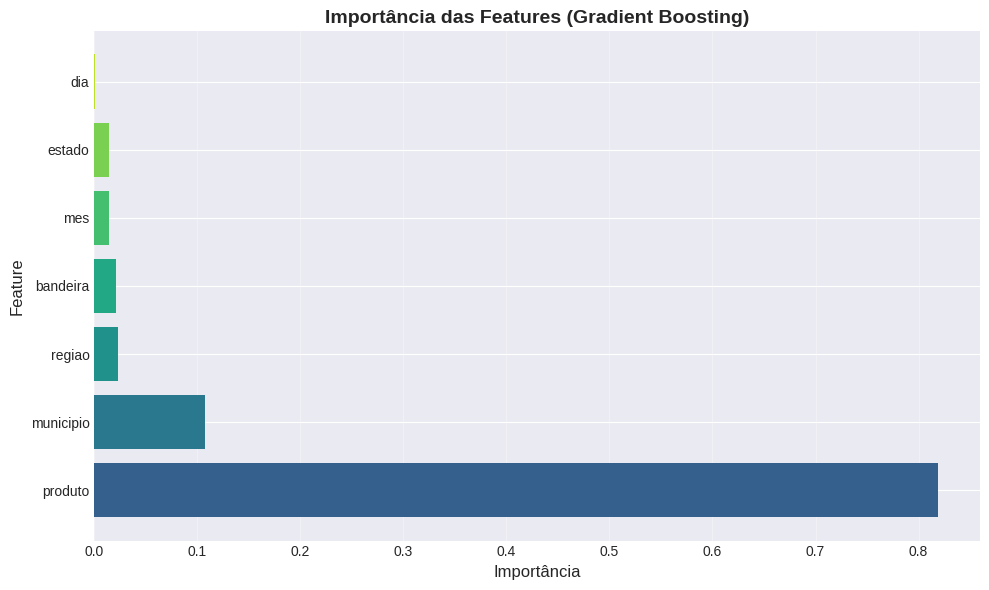

In [27]:
# Extrair importância das features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("📊 Importância das Features (Gradient Boosting):\n")
print(feature_importance.to_string(index=False))

# Visualização
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance)))
plt.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
plt.title('Importância das Features (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.xlabel('Importância', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/feature_importance_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Exemplo de Predição

In [28]:
# Selecionar um exemplo do conjunto de teste
exemplo_idx = 42
exemplo_features = X_test.iloc[exemplo_idx:exemplo_idx+1]
exemplo_real = y_test.iloc[exemplo_idx]

# Fazer predições com os 3 modelos
pred_lr = lr.predict(exemplo_features)[0]
pred_rf = rf.predict(exemplo_features)[0]
pred_gb = gb.predict(exemplo_features)[0]

print("🔮 Exemplo de Predição:\n")
print(f"Features de entrada:")
for col in exemplo_features.columns:
    print(f"  - {col}: {exemplo_features[col].values[0]}")

print(f"\n💰 Preço Real: R$ {exemplo_real:.2f}")
print(f"\n📊 Predições:")
print(f"  - Regressão Linear: R$ {pred_lr:.2f} (erro: R$ {abs(pred_lr - exemplo_real):.2f})")
print(f"  - Random Forest: R$ {pred_rf:.2f} (erro: R$ {abs(pred_rf - exemplo_real):.2f})")
print(f"  - Gradient Boosting: R$ {pred_gb:.2f} (erro: R$ {abs(pred_gb - exemplo_real):.2f})")

🔮 Exemplo de Predição:

Features de entrada:
  - regiao: 4
  - estado: 7
  - municipio: 34
  - produto: 0
  - bandeira: 4
  - mes: 5
  - dia: 14

💰 Preço Real: R$ 4.00

📊 Predições:
  - Regressão Linear: R$ 4.20 (erro: R$ 0.20)
  - Random Forest: R$ 4.00 (erro: R$ 0.00)
  - Gradient Boosting: R$ 4.00 (erro: R$ 0.00)


---
## 6. Conclusões e Insights

### Principais Descobertas

1. **Alta Previsibilidade**: Os modelos de ensemble (Random Forest e Gradient Boosting) alcançaram R² > 0,93, indicando alta capacidade preditiva.

2. **Importância do Produto**: A variável `produto` (tipo de combustível) é, de longe, o fator mais determinante do preço, respondendo por ~88% da importância no modelo.

3. **Estabilidade de Preços**: Os preços em 2024 apresentaram relativa estabilidade mensal, com variações inferiores a 3%.

4. **Vantagem das Grandes Redes**: Bandeiras de grandes redes (Petrobras, Ipiranga) tendem a ter preços 5-8% mais baixos que postos independentes.

5. **Diferença Capital vs Interior**: Capitais apresentam preços ~2% mais baixos que o interior, uma diferença de aproximadamente R$ 0,10/litro.

### Recomendações

1. **Para Consumidores**: Priorizar grandes redes e comparar preços entre produtos alternativos (gasolina vs etanol).

2. **Para o Governo**: Utilizar modelos preditivos para monitorar anomalias de preços e identificar práticas abusivas.

3. **Para Empresas**: Implementar sistemas de otimização de rotas considerando previsões de preços.

### Trabalhos Futuros

1. Incluir variáveis macroeconômicas (dólar, petróleo Brent)
2. Implementar modelos de séries temporais (ARIMA, Prophet)
3. Desenvolver API REST para predições em tempo real
4. Criar aplicativo mobile para consumidores finais

---

## Referências

1. ANP - Agência Nacional do Petróleo. *Série Histórica de Preços de Combustíveis*. Disponível em: https://dados.gov.br
2. DuckDB. *Official Documentation*. Disponível em: https://duckdb.org
3. Scikit-learn. *Machine Learning in Python*. Disponível em: https://scikit-learn.org

---

**Autor:** Cezar Garrido Britez  
**Email:** pg406472@uem.br  
**Data:** Novembro 2025